In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",")

t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})
t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

In [9]:
t11 = pd.read_excel("Tabela 1.1.1.xls", skiprows=8, header=None)
t11.columns = [
    "Estado", "total_geral", "total_branca", "total_preta_parda",
    "homens_branca", "homens_preta_parda", "mulheres_branca", "mulheres_preta_parda",
]

estados_validos = [
    "Rondônia", "Acre", "Amazonas", "Roraima", "Pará", "Amapá", "Tocantins",
    "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte", "Paraíba", "Pernambuco",
    "Alagoas", "Sergipe", "Bahia", "Minas Gerais", "Espírito Santo",
    "Rio de Janeiro", "São Paulo", "Paraná", "Santa Catarina", "Rio Grande do Sul",
    "Mato Grosso do Sul", "Mato Grosso", "Goiás", "Distrito Federal",
]
t11 = t11[t11["Estado"].isin(estados_validos)].reset_index(drop=True)


In [10]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")

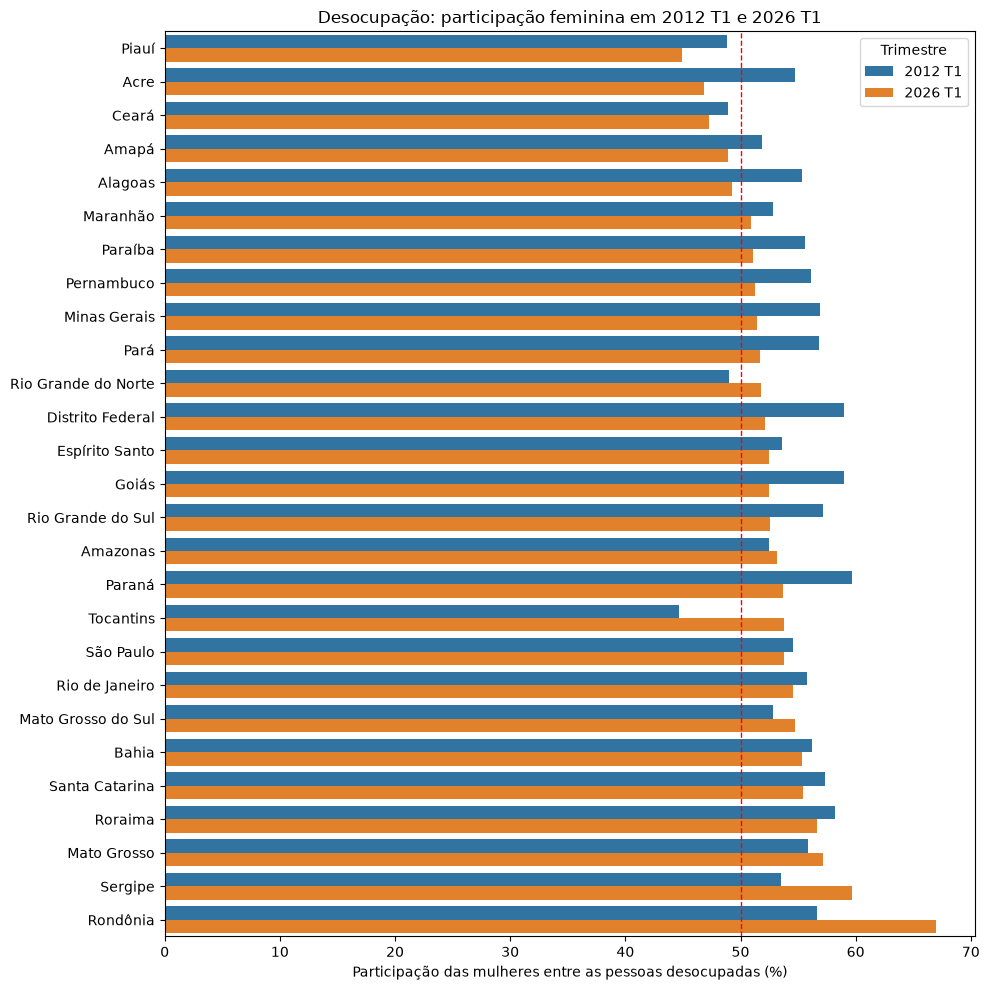

In [11]:
ordem = comp.sort_values("mulheres_2026")["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Trimestre")
fig.tight_layout()
plt.show()